# Brain Tumor MRI Classification using PyTorch

---
#### DISCLAIMER: THIS IS NOT MEDICAL ADVICE, DO NOT SELF DIAGNOSE

## Imports and loading data

In [1]:
import torch
from torch import nn, optim
from torch.nn import Flatten
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# use gpu if it's available if not cpu which is much slower
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Image transformations
Certain transformations are needed before using an image, e.g resize, changing to tensor and normalizing

In [2]:
# Every image will go through this transformation pipeline
pic_trans = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [3]:
train_dl = DataLoader(
    datasets.ImageFolder('data/Training', pic_trans),
    batch_size=32,
    shuffle=True,
    num_workers=4, # speeds up loading data
    pin_memory=True
)

test_dl = DataLoader(
    datasets.ImageFolder('data/Testing', pic_trans),
    batch_size=32,
    shuffle=False, # there is no need to shuffle, as this is just for evaluation
    num_workers=4, # speeds up loading data
    pin_memory=True
)

## Define model

In [4]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 4) # final layer, which takes 256 as input and 4 as output (4 classes
).to(device)

In [5]:
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

## Training loop

In [6]:
for epoch in range(25):
    running_loss = 0

    for x, y in train_dl:
        opt.zero_grad()

        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()

        running_loss += loss.item()
        opt.step()

    print(f'Epoch {epoch+1}: Loss was {running_loss}')

Epoch 1: Loss was 130.75669759511948
Epoch 2: Loss was 73.63938298821449
Epoch 3: Loss was 53.17228566110134
Epoch 4: Loss was 38.149181976914406
Epoch 5: Loss was 27.939862875267863
Epoch 6: Loss was 19.415074149146676
Epoch 7: Loss was 15.653259431011975
Epoch 8: Loss was 10.908003526041284
Epoch 9: Loss was 10.359763358253986
Epoch 10: Loss was 8.872038186702412
Epoch 11: Loss was 5.5267757285619155
Epoch 12: Loss was 5.179060830385424
Epoch 13: Loss was 5.312843189392879
Epoch 14: Loss was 4.755880499149498
Epoch 15: Loss was 5.7228535554531845
Epoch 16: Loss was 4.734982985610259
Epoch 17: Loss was 3.089457645000948
Epoch 18: Loss was 5.605053464842058
Epoch 19: Loss was 3.4980631136131706
Epoch 20: Loss was 4.662120238535863
Epoch 21: Loss was 4.505025262311392
Epoch 22: Loss was 2.5882088080415997
Epoch 23: Loss was 2.989620390564596
Epoch 24: Loss was 2.832615297735174
Epoch 25: Loss was 2.3558883950936433


In [9]:
model.eval()
test_loss, correct = 0.0, 0
with torch.no_grad():
    for x, y in test_dl:
        y, y = x.to(device), y.to(device)

        logits = model(x)
        test_loss = loss_fn(logits, y).item() * y.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).float().sum().item()

test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct / len(test_dl.dataset)

print(f'Test set: Average loss: {test_loss}, Accuracy: {accuracy}')

Test set: Average loss: 0.0003493921458721161, Accuracy: 91.9375


Decent with room for improvement ;))

## Visualising image

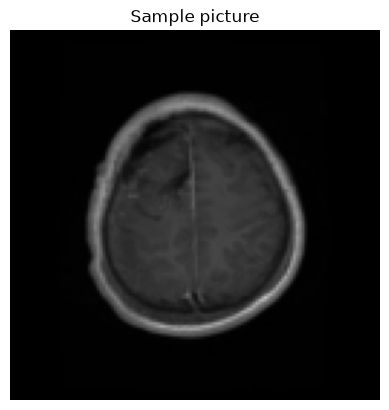

Predicted: glioma
Actual: glioma


In [8]:
import random
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

unnorm = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample picture')
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(dim=1).item()

class_names = test_dl.dataset.classes
print(f'Predicted: {class_names[pred]}')
print(f'Actual: {class_names[label]}')